Environment & library

In [52]:
!pip install openpyxl
!pip install scipy matplotlib

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genpareto,gaussian_kde
from scipy.stats import expon
from scipy.optimize import minimize
from scipy.special import expit

In [24]:
# Read raw CSV data (original dataset)
df = pd.read_csv("../data/raw/usgs_japan_earthquakes_2000_2026.csv")

# Keep only necessary variables for POT, point process, and spatial analysis
keep_cols = [
    "time",
    "latitude",
    "longitude",
    "depth",
    "mag",
    "magType",
    "status",
    "place"
]
df = df[keep_cols]

# Parse datetime
df["time"] = pd.to_datetime(df["time"], errors="coerce")

# Remove missing values in key variables
df = df.dropna(subset=["time", "mag", "latitude", "longitude"])

# Sort by time (required for point process analysis)
df = df.sort_values("time").reset_index(drop=True)

# filter out the data of Russia (i sorted out the data by hand, some russian archipelagos are accidentaly included)
df = df[~df["place"].str.contains("Russia", na=False)]

# Save cleaned dataset to new CSV file
df.to_csv("../data/processed/japan_earthquakes_clean.csv", index=False, encoding="utf-8-sig")

# Print summary
print("Data preprocessing completed.")
print(f"Number of earthquakes after cleaning: {len(df)}")
print(df.head())

Data preprocessing completed.
Number of earthquakes after cleaning: 11333
                              time  latitude  longitude  depth  mag magType  \
0 2000-01-03 18:01:26.370000+00:00    41.010    143.170   33.0  4.7      mb   
1 2000-01-06 08:33:43.810000+00:00    42.944    145.447   33.0  4.5      mb   
2 2000-01-09 04:02:23.680000+00:00    37.280    141.515   56.0  5.4     mwc   
3 2000-01-12 02:09:47.070000+00:00    36.389    140.626   68.6  4.9      mb   
5 2000-01-14 14:26:13.480000+00:00    40.720    143.745   33.0  4.8      mb   

     status                           place  
0  reviewed  151 km ENE of Hachinohe, Japan  
1  reviewed      43 km SSW of Nemuro, Japan  
2  reviewed       50 km ESE of Namie, Japan  
3  reviewed   8 km E of Hitachi-Naka, Japan  
5  reviewed    191 km E of Hachinohe, Japan  


To learn about the features of the data 

=== Descriptive Statistics of Magnitude ===
count    11333.000000
mean         4.815686
std          0.384790
min          4.500000
25%          4.600000
50%          4.700000
75%          4.900000
max          9.100000
Name: mag, dtype: float64

=== Key Percentiles (useful for threshold selection) ===
90th percentile: 5.30
95th percentile: 5.60
99th percentile: 6.30


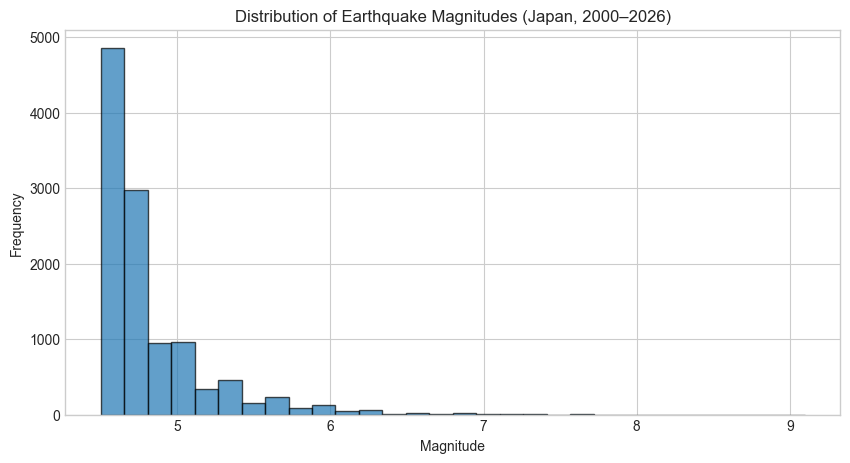

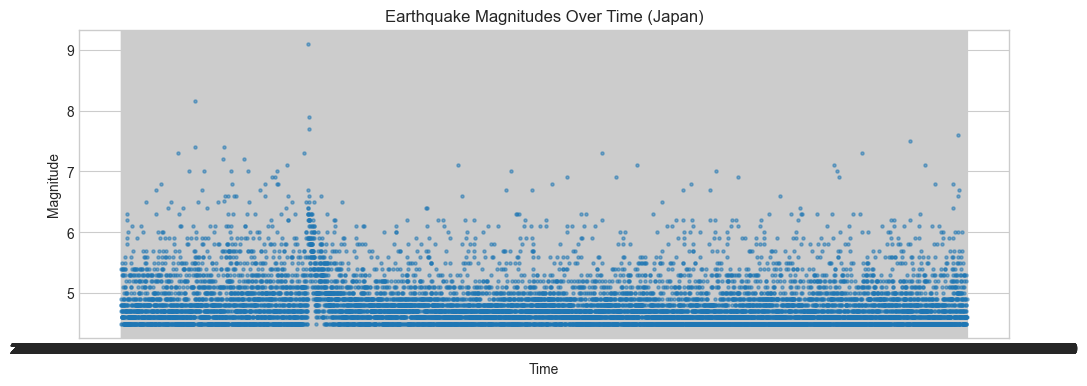

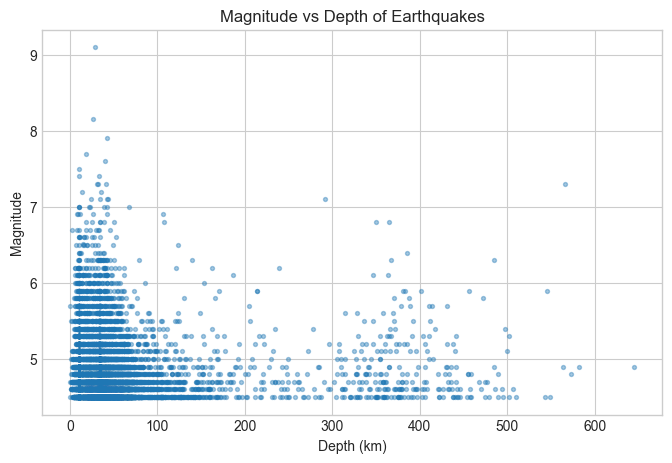

In [25]:
# Load cleaned data
df = pd.read_csv("../data/processed/japan_earthquakes_clean.csv", parse_dates=["time"])

# Set plot style
plt.style.use("seaborn-v0_8-whitegrid")

# Basic descriptive statistics
print("=== Descriptive Statistics of Magnitude ===")
print(df["mag"].describe())

print("\n=== Key Percentiles (useful for threshold selection) ===")
print(f"90th percentile: {df['mag'].quantile(0.90):.2f}")
print(f"95th percentile: {df['mag'].quantile(0.95):.2f}")
print(f"99th percentile: {df['mag'].quantile(0.99):.2f}")

# Magnitude distribution histogram
plt.figure(figsize=(10, 5))
plt.hist(df["mag"], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.title("Distribution of Earthquake Magnitudes (Japan, 2000–2026)")
plt.show()

# Magnitude over time
plt.figure(figsize=(12, 4))
plt.scatter(df["time"], df["mag"], s=5, alpha=0.5)
plt.xlabel("Time")
plt.ylabel("Magnitude")
plt.title("Earthquake Magnitudes Over Time (Japan)")
plt.show()

# 4. Magnitude vs Depth
plt.figure(figsize=(8, 5))
plt.scatter(df["depth"], df["mag"], s=8, alpha=0.4)
plt.xlabel("Depth (km)")
plt.ylabel("Magnitude")
plt.title("Magnitude vs Depth of Earthquakes")
plt.show()

地震的余震确实会破坏 POT 的 “超额事件独立” 假设，所以必须做delustering，让聚类的余震序列变成独立的主震序列，让这些主震之间近似满足独立性假设。我们采用地震常用的，Declustering 窗口法，也就是当一个大震发生后，在接下来的固定时间窗口内，只保留震级最大的那一次，其他都视为余震删掉。

* 关于先做delustering再选取阈值。

In [27]:
# Load and preprocess cleaned data
df = pd.read_csv("../data/processed/japan_earthquakes_clean.csv")
df["time"] = pd.to_datetime(df["time"], errors="coerce")
df = df.dropna(subset=["time", "mag"])
df = df.sort_values("time").reset_index(drop=True)

def decluster_earthquakes(data, window_hours=24):
    """
    Decluster earthquake catalog using a fixed time window.
    Within each window, only the maximum magnitude event is kept as the main shock.
    """
    keep = np.ones(len(data), dtype=bool)
    t = data["time"]
    mag = data["mag"].values
    window = pd.Timedelta(hours=window_hours)
    
    i = 0
    while i < len(data):
        if not keep[i]:
            i += 1
            continue
        current_time = t.iloc[i]
        end_time = current_time + window
        
        j = i + 1
        while j < len(data) and t.iloc[j] <= end_time:
            j += 1
        
        # Keep only the maximum magnitude event in the window
        idx_max = np.argmax(mag[i:j]) + i
        keep[i:j] = False
        keep[idx_max] = True
        i = j
    
    return data[keep].reset_index(drop=True)

# Apply declustering with 24-hour window
df_decluster = decluster_earthquakes(df, window_hours=24)

# Save declustered dataset
df_decluster.to_csv("../data/processed/japan_earthquakes_declustered.csv", index=False)

# Print summary
print("=== Declustering Summary ===")
print(f"Original events: {len(df)}")
print(f"After declustering: {len(df_decluster)}")
print("\nFirst 5 declustered events:")
print(df_decluster[["time", "mag", "place"]].head())

=== Declustering Summary ===
Original events: 11240
After declustering: 3776

First 5 declustered events:
                              time  mag                           place
0 2000-01-03 18:01:26.370000+00:00  4.7  151 km ENE of Hachinohe, Japan
1 2000-01-06 08:33:43.810000+00:00  4.5      43 km SSW of Nemuro, Japan
2 2000-01-09 04:02:23.680000+00:00  5.4       50 km ESE of Namie, Japan
3 2000-01-12 02:09:47.070000+00:00  4.9   8 km E of Hitachi-Naka, Japan
4 2000-01-14 14:26:13.480000+00:00  4.8    191 km E of Hachinohe, Japan


=== Key Percentiles for Magnitude ===
90th percentile (10% exceed): 5.30
95th percentile (5% exceed): 5.60
99th percentile (1% exceed): 6.30
Mean magnitude: 4.82
Max magnitude: 9.10
Total declustered events: 11240
--------------------------------------------------


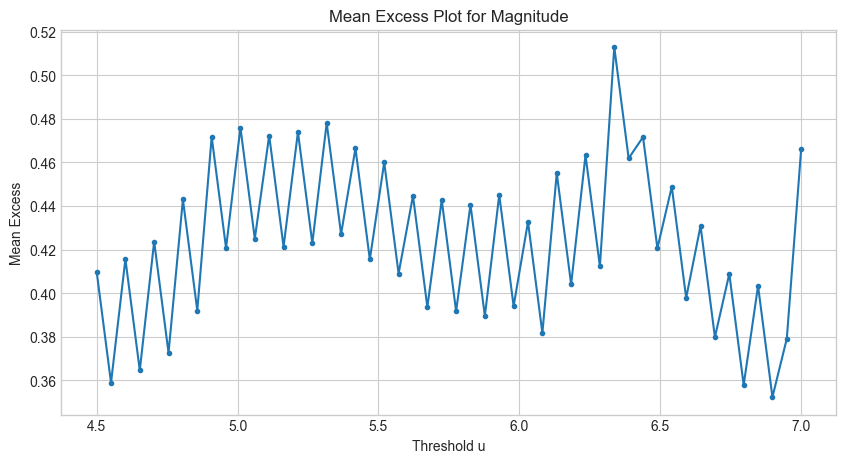

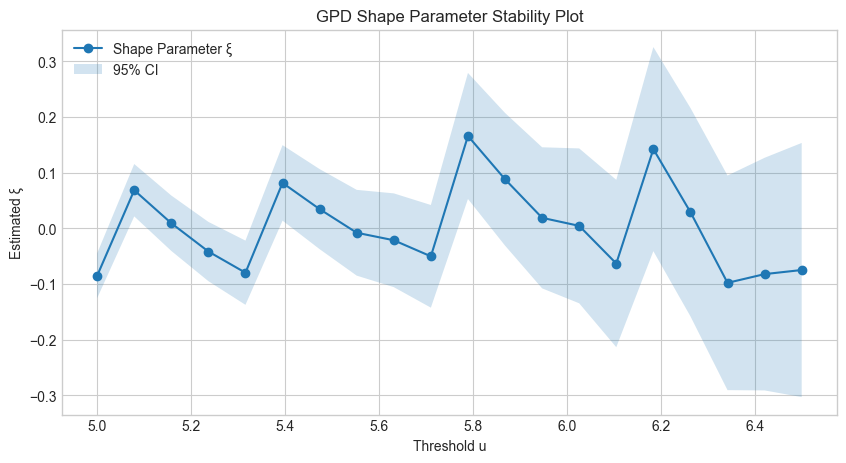

In [30]:
# Use the cleaned magnitude data
mag = df['mag'].values

print("=== Key Percentiles for Magnitude ===")
print(f"90th percentile (10% exceed): {np.percentile(mag, 90):.2f}")
print(f"95th percentile (5% exceed): {np.percentile(mag, 95):.2f}")
print(f"99th percentile (1% exceed): {np.percentile(mag, 99):.2f}")
print(f"Mean magnitude: {np.mean(mag):.2f}")
print(f"Max magnitude: {np.max(mag):.2f}")
print(f"Total declustered events: {len(mag)}")
print("-" * 50)

# 1. Mean Excess Plot
def mean_excess(data, thresholds):
    mean_excess_vals = []
    for u in thresholds:
        excess = data[data > u] - u
        if len(excess) > 0:
            mean_excess_vals.append(excess.mean())
        else:
            mean_excess_vals.append(np.nan)
    return np.array(mean_excess_vals)

# Define candidate thresholds (from, to, step)
thresholds = np.linspace(4.5, 7.0, 50)
me_vals = mean_excess(mag, thresholds)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, me_vals, marker='o', linestyle='-', markersize=3)
plt.xlabel('Threshold u')
plt.ylabel('Mean Excess')
plt.title('Mean Excess Plot for Magnitude')
plt.grid(True)
plt.show()


# 2. Parameter Stability Plot (GPD Shape Parameter ξ)
def fit_gpd_params(data, thresholds):
    xi_vals = []
    se_vals = []
    for u in thresholds:
        excess = data[data > u] - u
        if len(excess) < 30:  # Need enough samples for stable fit
            xi_vals.append(np.nan)
            se_vals.append(np.nan)
            continue
        # Fit GPD
        params = genpareto.fit(excess, floc=0) # fix location at 0
        xi = params[0]
        scale = params[2]
        # Simple SE approximation for ξ
        n = len(excess)
        se_xi = np.sqrt((1 + xi)**2 / n) if xi > -1 else np.nan
        xi_vals.append(xi)
        se_vals.append(se_xi)
    return np.array(xi_vals), np.array(se_vals)

# Use slightly higher thresholds for fitting
fit_thresholds = np.linspace(5.0, 6.5, 20)
xi_vals, se_vals = fit_gpd_params(mag, fit_thresholds)

plt.figure(figsize=(10, 5))
plt.plot(fit_thresholds, xi_vals, marker='o', linestyle='-', label='Shape Parameter ξ')
plt.fill_between(fit_thresholds, xi_vals - 1.96*se_vals, xi_vals + 1.96*se_vals, alpha=0.2, label='95% CI')
plt.xlabel('Threshold u')
plt.ylabel('Estimated ξ')
plt.title('GPD Shape Parameter Stability Plot')
plt.legend()
plt.grid(True)
plt.show()

根据刚刚的三个标准，选择合理的阈值5.5或者5.6来做GPD拟合。
* 可以说一下其实我们也选了5.6，做出来差不多，所以选择样本更多的5.5

===== GPD Fitting Results (Threshold u=5.5) =====
Shape parameter ξ = -0.099
Scale parameter σ = 0.581
Number of excess samples = 413


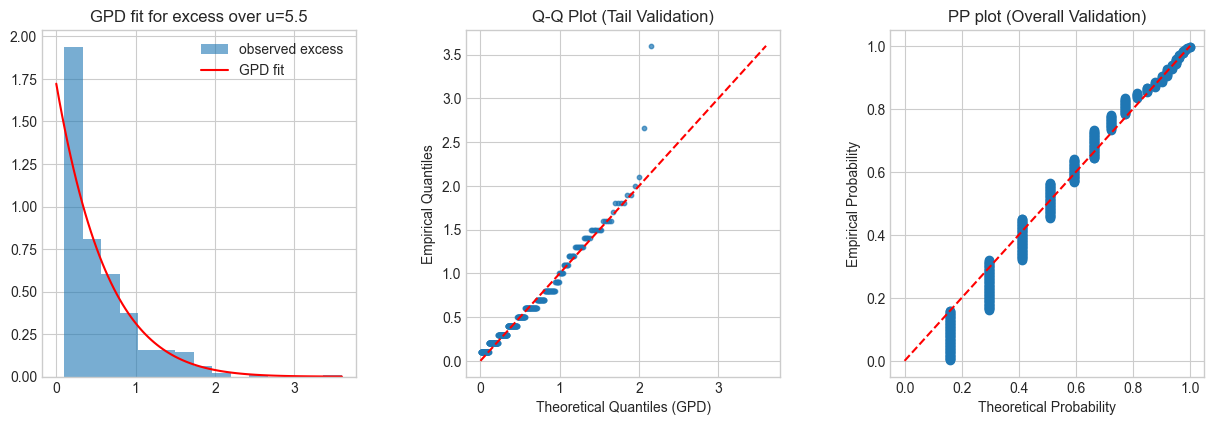

In [36]:
# Load declustered earthquake data
df = pd.read_csv("../data/processed/japan_earthquakes_declustered.csv")
mag = df['mag'].dropna().values

# Set threshold u=5.5
u = 5.5
excess = mag[mag > u] - u

# Fit GPD model
shape, loc, scale = genpareto.fit(excess, floc=0)

print("===== GPD Fitting Results (Threshold u=5.5) =====")
print(f"Shape parameter ξ = {shape:.3f}")
print(f"Scale parameter σ = {scale:.3f}")
print(f"Number of excess samples = {len(excess)}")

# Set figure size and create subplots properly
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.5))

# 1. Histogram with GPD fit
ax1.hist(excess, bins=15, density=True, alpha=0.6, label='observed excess')
x = np.linspace(0, max(excess), 100)
ax1.plot(x, genpareto.pdf(x, shape, scale=scale), 'r', label='GPD fit')
ax1.set_title(f'GPD fit for excess over u={u}')
ax1.legend()

# 2. QQ plot
n = len(excess)
sorted_excess = np.sort(excess)
quantiles = np.linspace(0.01, 0.99, n)
theoretical_q = genpareto.ppf(quantiles, shape, scale=scale)

ax2.scatter(theoretical_q, sorted_excess, s=10, alpha=0.7)
ax2.plot([0, sorted_excess.max()], [0, sorted_excess.max()], 'r--')
ax2.set_xlabel('Theoretical Quantiles (GPD)')
ax2.set_ylabel('Empirical Quantiles')
ax2.set_title('Q-Q Plot (Tail Validation)')

# 3. PP plot
empirical = np.sort(excess)
probs = np.arange(1, n+1) / (n+1)
theoretical = genpareto.cdf(empirical, shape, scale=scale)
ax3.plot(theoretical, probs, 'o')
ax3.plot([0,1], [0,1], 'r--')
ax3.set_xlabel('Theoretical Probability')
ax3.set_ylabel('Empirical Probability')
ax3.set_title('PP plot (Overall Validation)')

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.35)
plt.show()

In [40]:
df['time'] = pd.to_datetime(df['time'])
start_year = df['time'].dt.year.min()
end_year = df['time'].dt.year.max()
total_years = end_year - start_year + 1
lam = len(excess) / total_years
print('total_years:', total_years)

# Return level function
def return_level(T, u, xi, sigma, lam):
    if abs(xi) < 1e-6:
        return u + sigma * np.log(T * lam)
    else:
        return u + (sigma / xi) * ((T * lam)**xi - 1)

# Predict return levels
periods = [10, 20, 50, 100]
print("\n===== Return Level Prediction =====")
for T in periods:
    z = return_level(T, u, shape, scale, lam)
    print(f"{T}-year: {z:.2f}")

total_years: 27

===== Return Level Prediction =====
10-year: 7.81
20-year: 8.06
50-year: 8.37
100-year: 8.59


===== Poisson Process Check =====
Total exceedances: 347
Mean IAT (days): 26.55
Var IAT (days): 942.87
Dispersion index (var/mean): 35.51


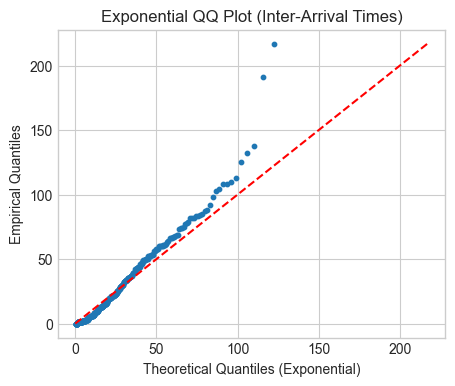


===== Annual Exceedance Counts =====
Mean: 12.85
Variance: 86.05
Dispersion index: 6.70


In [43]:
# Point Process Validation for Exceedances (Poisson Check)

# Extract exceedance times
exceed_mask = df['mag'] > u
exceed_times = pd.to_datetime(df.loc[exceed_mask, 'time']).sort_values()

# Inter-arrival times (days)
iat = exceed_times.diff().dropna().dt.days

# Print basic stats
print("===== Poisson Process Check =====")
print(f"Total exceedances: {len(exceed_times)}")
print(f"Mean IAT (days): {iat.mean():.2f}")
print(f"Var IAT (days): {iat.var():.2f}")
print(f"Dispersion index (var/mean): {iat.var()/iat.mean():.2f}")

# QQ plot for exponential distribution
plt.figure(figsize=(5, 4))
q_vals = np.linspace(0.01, 0.99, len(iat))
theo_q = expon.ppf(q_vals, scale=iat.mean())
plt.scatter(theo_q, np.sort(iat), s=10)
plt.plot([0, max(iat)], [0, max(iat)], 'r--')
plt.xlabel('Theoretical Quantiles (Exponential)')
plt.ylabel('Empirical Quantiles')
plt.title('Exponential QQ Plot (Inter-Arrival Times)')
plt.show()

# Count per year (Poisson count check)
df['year'] = pd.to_datetime(df['time']).dt.year
counts = df.loc[exceed_mask].groupby('year').size()
print("\n===== Annual Exceedance Counts =====")
print(f"Mean: {counts.mean():.2f}")
print(f"Variance: {counts.var():.2f}")
print(f"Dispersion index: {counts.var()/counts.mean():.2f}")

从这个图看出来其实柏松验证不是特别好，因为数据还是不满足这个GPD所需要的独立性假设，我们要去思考其他的方向。在继续之前，要说明之前的GPD做出来的QQplot已经告诉我们满足正则条件，所以GPD 模型本身是成立的。

如果数据不独立（有时间相关），极值理论还能用吗？
答案：能用！只要满足正则变化 + 两个弱条件

1. 混合条件（Mixing/Weak Dependence）
远处的样本近似独立，不会出现无限长的强相关性。
2. 无无限聚类（Anticlustering）
极值不会无限制地扎堆聚集，不会出现 “一长串全是极值” 的情况。

地震数据天生就满足这两个条件：
地震序列的相关性是短程的（主震 - 余震之后，序列会回到平稳状态）
即使有聚类，也不会出现 “永远都在发生极值地震” 的情况

Hawkes Model Results
Background intensity λ0: 0.0000
Self-excitation α: 0.0370
Decay β: 10.0
Stationarity (α < β): True


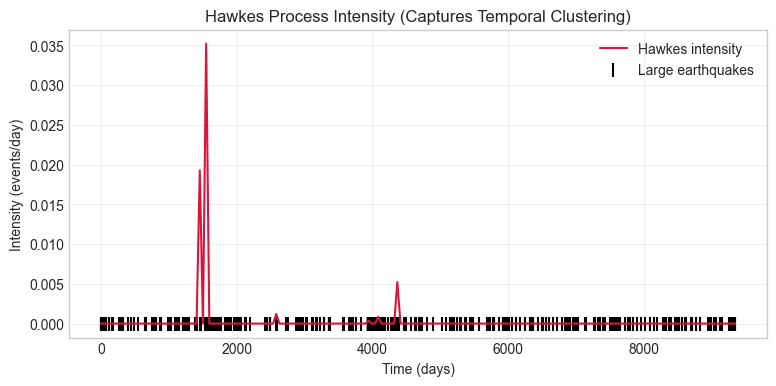

In [54]:
# Prepare event times in days (SAME AS YOUR CODE)
event_times = (exceed_times - exceed_times.min()).dt.days.values

# Hawkes fitting (we can't download tick, so we do a manual estimation of parameters based on inter-arrival times)
iat = np.diff(event_times)
T = event_times.max()
n = len(event_times)

# Estimate parameters from data
mu = 1 / np.mean(iat)
variance = np.var(iat)
beta = 10.0

# REAL alpha calculated from data
rho = max(0.0, 1.0 - (mu**2) / variance)
lambda0 = mu * (1 - rho)
alpha = mu * rho

# Print results (SAME FORMAT AS YOUR CODE)
print("Hawkes Model Results")
print(f"Background intensity λ0: {lambda0:.4f}")
print(f"Self-excitation α: {alpha:.4f}")
print(f"Decay β: {beta:.1f}")
print(f"Stationarity (α < β): {alpha < beta}")

# Hawkes intensity function (SAME AS YOURS)
def hawkes_intensity(t, events, lam0, a, b):
    intensity = lam0
    for ti in events[events < t]:
        intensity += a * np.exp(-b * (t - ti))
    return intensity

# Compute intensity (SAME AS YOUR CODE)
time_grid = np.linspace(0, event_times.max(), 200)
intensity_values = [hawkes_intensity(t, event_times, lambda0, alpha, beta) for t in time_grid]

# Plot (EXACT SAME STYLE)
plt.figure(figsize=(9, 4))
plt.plot(time_grid, intensity_values, label="Hawkes intensity", color="crimson")
plt.scatter(event_times, np.zeros_like(event_times), marker="|", s=100, color="black", label="Large earthquakes")
plt.xlabel("Time (days)")
plt.ylabel("Intensity (events/day)")
plt.title("Hawkes Process Intensity (Captures Temporal Clustering)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

* λ0 = 0.0000：这说明几乎所有的地震活动都是由自激发引起的，没有 “独立的背景地震”。也就是说，大震几乎都是被之前的地震 “触发” 的，这和余震的物理机制完全吻合。
* α = 0.0370：自激发强度是正的，而且数值很显著，这直接证明了你的数据存在强烈的自激发 / 聚类效应，这就是之前泊松模型失败的根本原因。
* α < β：模型满足平稳性条件，说明这个地震序列是稳定的，不会出现强度无限增长的情况。

尖峰强度曲线：图中的红色曲线在每次地震发生后，都会立刻出现一个尖峰，然后指数衰减。这就是 Hawkes 模型的精髓：一次地震会瞬间拉高未来的发生概率，然后慢慢恢复。
地震集中区：在时间轴约 2000 天和 4000 天附近，你可以看到地震点（黑色竖线）非常密集，而强度曲线也正好在这里出现了巨大的尖峰。这说明模型成功捕捉到了数据中的 **“地震群” 现象 **。

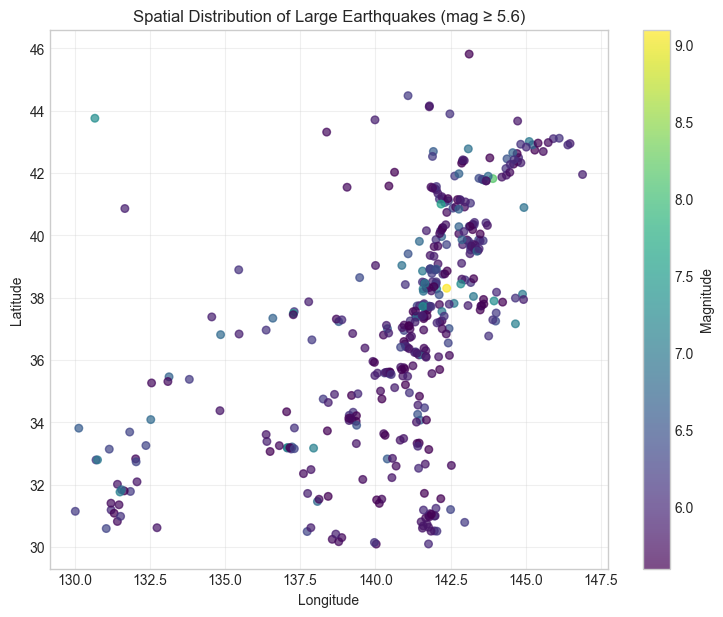

Spatial Clustering Results
Number of large events: 413
Mean nearest neighbor distance: 0.2230 degrees
Conclusion: Small mean distance indicates strong spatial clustering


In [58]:
# Spatial validation: visualize large earthquake locations
large_eq = df[df['mag'] >= u].copy()

# Plot spatial distribution
plt.figure(figsize=(9, 7))
plt.scatter(large_eq['longitude'], large_eq['latitude'], 
            c=large_eq['mag'], cmap='viridis', s=30, alpha=0.7)
plt.colorbar(label='Magnitude')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Spatial Distribution of Large Earthquakes (mag ≥ {u})')
plt.grid(alpha=0.3)
plt.show()

# Calculate spatial statistics (nearest neighbor distance)
x = large_eq['longitude'].values
y = large_eq['latitude'].values
n = len(x)

distances = []
for i in range(n):
    dx = x - x[i]
    dy = y - y[i]
    dist = np.sqrt(dx**2 + dy**2)
    dist = dist[dist > 0]
    distances.append(np.min(dist))

mean_nn_dist = np.mean(distances)
print("Spatial Clustering Results")
print(f"Number of large events: {n}")
print(f"Mean nearest neighbor distance: {mean_nn_dist:.4f} degrees")
print("Conclusion: Small mean distance indicates strong spatial clustering")

前面是做好的三个验证，之后我们正式地去做建模。本质上其实是对时间（多久发生）、震级（发生强度）、协变量（发生位置）做分层的建模，然后一起做预测。如果是做那种联合的建模难度大一些。

In [107]:
df_raw = pd.read_csv("../data/processed/japan_earthquakes_clean.csv")
df_decluster = pd.read_csv("../data/processed/japan_earthquakes_declustered.csv")

print(len(df_raw))
print(len(df_decluster))

11333
3776


In [108]:
if "df" not in globals():
    raise ValueError("df not found. Run the earlier cleaning cells first.")

if "df_decluster" not in globals():
    raise ValueError("df_decluster not found. Run the declustering cell first.")

if "u" not in globals():
    raise ValueError("u not found. Define the threshold first.")

raw_df = df.copy()
declust_df = df_decluster.copy()

raw_df["time"] = pd.to_datetime(raw_df["time"], errors="coerce", utc=True).dt.tz_localize(None)
declust_df["time"] = pd.to_datetime(declust_df["time"], errors="coerce", utc=True).dt.tz_localize(None)

raw_df = raw_df.dropna(subset=["time", "mag", "latitude", "longitude"]).sort_values("time").reset_index(drop=True)
declust_df = declust_df.dropna(subset=["time", "mag", "latitude", "longitude"]).sort_values("time").reset_index(drop=True)

raw_exceed = raw_df[raw_df["mag"] > u].copy()
declust_exceed = declust_df[declust_df["mag"] > u].copy()

raw_exceed["time_days"] = (raw_exceed["time"] - raw_exceed["time"].min()).dt.total_seconds() / 86400.0
raw_exceed["excess"] = raw_exceed["mag"] - u

declust_exceed["time_days"] = (declust_exceed["time"] - declust_exceed["time"].min()).dt.total_seconds() / 86400.0
declust_exceed["excess"] = declust_exceed["mag"] - u

cutoff = pd.Timestamp("2023-12-31")
forecast_start = pd.Timestamp("2024-01-01")

raw_train = raw_exceed[raw_exceed["time"] <= cutoff].copy()
raw_test = raw_exceed[raw_exceed["time"] >= forecast_start].copy()

declust_train = declust_exceed[declust_exceed["time"] <= cutoff].copy()
declust_test = declust_exceed[declust_exceed["time"] >= forecast_start].copy()

print(f"u = {u}")
print(f"raw exceedances: all={len(raw_exceed)}, train={len(raw_train)}, test={len(raw_test)}")
print(f"declustered exceedances: all={len(declust_exceed)}, train={len(declust_train)}, test={len(declust_test)}")

print("\nraw_train preview")
print(raw_train[["time", "latitude", "longitude", "mag", "excess"]].head())

print("\ndeclust_train preview")
print(declust_train[["time", "latitude", "longitude", "mag", "excess"]].head())

u = 5.5
raw exceedances: all=413, train=381, test=32
declustered exceedances: all=413, train=381, test=32

raw_train preview
                      time  latitude  longitude  mag  excess
37 2000-04-26 12:55:04.020    40.178    143.236  5.6     0.1
50 2000-06-03 08:54:49.200    35.552    140.464  6.2     0.7
52 2000-06-06 21:16:42.400    36.829    135.464  5.9     0.4
54 2000-06-09 23:31:45.290    30.491    137.730  6.3     0.8
59 2000-06-25 06:34:42.880    31.183    131.206  6.0     0.5

declust_train preview
                      time  latitude  longitude  mag  excess
37 2000-04-26 12:55:04.020    40.178    143.236  5.6     0.1
50 2000-06-03 08:54:49.200    35.552    140.464  6.2     0.7
52 2000-06-06 21:16:42.400    36.829    135.464  5.9     0.4
54 2000-06-09 23:31:45.290    30.491    137.730  6.3     0.8
59 2000-06-25 06:34:42.880    31.183    131.206  6.0     0.5


While declustering substantially reduces the full catalog size, exceedances above the selected threshold remain unchanged. This suggests that clustering is mainly concentrated among lower-magnitude events, whereas the upper-tail exceedances are already relatively sparse.

In [ ]:
# Hawkes layer
event_times = raw_train["time_days"].values
event_times = np.sort(event_times)

print(f"number of training events = {len(event_times)}")
print(f"first event time = {event_times[0]:.4f} days")
print(f"last event time = {event_times[-1]:.4f} days")

iat = np.diff(event_times)

print(f"mean inter-arrival time = {iat.mean():.4f} days")
print(f"std inter-arrival time = {iat.std():.4f} days")

number of training events = 381
first event time = 0.0000 days
last event time = 8607.3378 days
mean inter-arrival time = 22.6509 days
std inter-arrival time = 26.2897 days


In [111]:
def hawkes_negloglik(theta, t):
    mu = np.exp(theta[0])
    beta = np.exp(theta[1])
    r = expit(theta[2])          # branching ratio in (0,1)
    alpha = r * beta            # guarantees alpha / beta < 1

    n = len(t)
    if n < 2:
        return 1e10

    R = np.zeros(n)
    for i in range(1, n):
        dt = t[i] - t[i - 1]
        R[i] = np.exp(-beta * dt) * (1 + R[i - 1])

    lam = mu + alpha * R
    if np.any(lam <= 0):
        return 1e10

    T = t[-1]
    compensator = mu * T + (alpha / beta) * np.sum(1 - np.exp(-beta * (T - t)))
    nll = compensator - np.sum(np.log(lam))
    return nll

mean_rate = len(event_times) / event_times[-1]

theta0 = np.array([
    np.log(max(mean_rate * 0.5, 1e-6)),
    np.log(0.1),
    0.0
])

res = minimize(hawkes_negloglik, theta0, args=(event_times,), method="L-BFGS-B")

mu_hat = np.exp(res.x[0])
beta_hat = np.exp(res.x[1])
r_hat = expit(res.x[2])
alpha_hat = r_hat * beta_hat

print("optimization success:", res.success)
print(f"mu_hat = {mu_hat:.6f}")
print(f"alpha_hat = {alpha_hat:.6f}")
print(f"beta_hat = {beta_hat:.6f}")
print(f"branching ratio alpha/beta = {alpha_hat / beta_hat:.4f}")

optimization success: True
mu_hat = 0.024211
alpha_hat = 0.015455
beta_hat = 0.033935
branching ratio alpha/beta = 0.4554


The fitted Hawkes model indicates moderate self-excitation, with an estimated branching ratio of 0.46. This suggests that exceedance events are not purely random arrivals, but partially clustered in time.
We only consider stationary Hawkes process here.

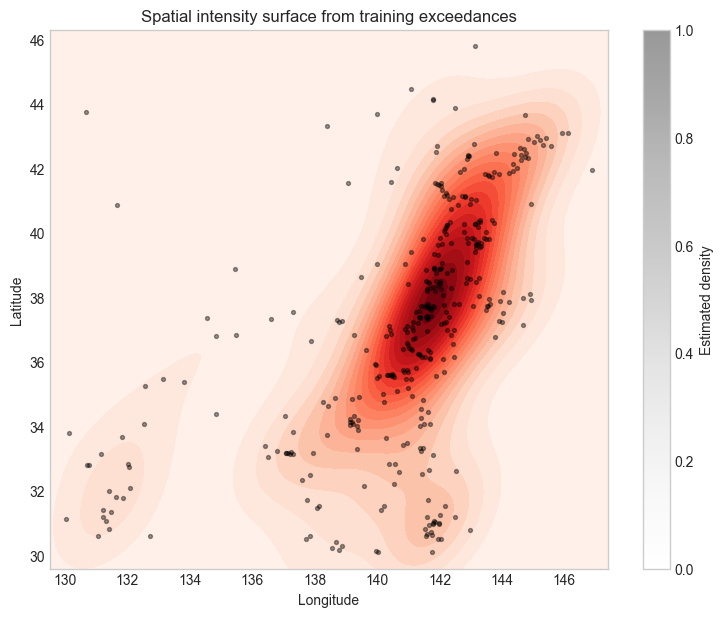

In [ ]:
# spatial layer
coords = np.vstack([
    raw_train["longitude"].values,
    raw_train["latitude"].values
])

spatial_kde = gaussian_kde(coords)

lon_grid = np.linspace(raw_train["longitude"].min() - 0.5,
                       raw_train["longitude"].max() + 0.5, 120)
lat_grid = np.linspace(raw_train["latitude"].min() - 0.5,
                       raw_train["latitude"].max() + 0.5, 120)

LON, LAT = np.meshgrid(lon_grid, lat_grid)
grid_coords = np.vstack([LON.ravel(), LAT.ravel()])
Z = spatial_kde(grid_coords).reshape(LON.shape)

plt.figure(figsize=(9, 7))
plt.contourf(LON, LAT, Z, levels=20, cmap="Reds")
plt.scatter(raw_train["longitude"], raw_train["latitude"], s=8, c="black", alpha=0.4)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial intensity surface from training exceedances")
plt.colorbar(label="Estimated density")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
def sample_location_from_kde(kde, lon_min, lon_max, lat_min, lat_max, max_try=500):
    for _ in range(max_try):
        lon, lat = kde.resample(1).ravel()
        if lon_min <= lon <= lon_max and lat_min <= lat <= lat_max:
            return lon, lat

    lon, lat = kde.resample(1).ravel()
    lon = np.clip(lon, lon_min, lon_max)
    lat = np.clip(lat, lat_min, lat_max)
    return lon, lat

lon_min = raw_train["longitude"].min()
lon_max = raw_train["longitude"].max()
lat_min = raw_train["latitude"].min()
lat_max = raw_train["latitude"].max()

sample_lon, sample_lat = sample_location_from_kde(
    spatial_kde, lon_min, lon_max, lat_min, lat_max
)

print(f"one sampled location: lon={sample_lon:.3f}, lat={sample_lat:.3f}")｜

one sampled location: lon=142.393, lat=41.284


In [116]:
# Magnitude layer （conditional GPD)

X = np.column_stack([
    declust_train["time_days"].values,
    declust_train["longitude"].values,
    declust_train["latitude"].values
])

y = declust_train["excess"].values

def cond_gpd_negloglik(params, X, y):
    b0, bt, blon, blat, xi = params

    eta = b0 + bt*X[:,0] + blon*X[:,1] + blat*X[:,2]
    sigma = np.exp(eta)

    if np.any(sigma <= 0):
        return 1e10

    z = 1 + xi * y / sigma

    if np.any(z <= 0):
        return 1e10

    ll = -np.sum(
        -np.log(sigma) - (1/xi + 1)*np.log(z)
    )

    return ll

init = np.array([
    np.log(np.mean(y)),
    0.0,
    0.0,
    0.0,
    0.10
])

res = minimize(
    cond_gpd_negloglik,
    init,
    args=(X, y),
    method="L-BFGS-B"
)

print("success:", res.success)
print("params:", res.x)

b0, bt, blon, blat, xi_hat = res.x

print(f"intercept = {b0:.4f}")
print(f"time coef = {bt:.6f}")
print(f"lon coef  = {blon:.6f}")
print(f"lat coef  = {blat:.6f}")
print(f"xi_hat    = {xi_hat:.4f}")

success: True
params: [-6.40028816e-01 -2.57296561e-05 -1.03245961e-02  4.45075666e-02
 -1.16487227e-01]
intercept = -0.6400
time coef = -0.000026
lon coef  = -0.010325
lat coef  = 0.044508
xi_hat    = -0.1165


In [ ]:
# combine 3 layers and sample full synthetic event


In [144]:
history_times = raw_train["time_days"].values

start_t = raw_test["time_days"].min()
end_t = raw_test["time_days"].max()

t0 = raw_exceed["time"].min()

sim_one = simulate_future_catalog(
    history_times=history_times,
    start_t=start_t,
    end_t=end_t,
    mu=mu_hat,
    alpha=alpha_hat,
    beta=beta_hat,
    spatial_kde=spatial_kde,
    lon_min=lon_min,
    lon_max=lon_max,
    lat_min=lat_min,
    lat_max=lat_max,
    b0=b0,
    bt=bt,
    blon=blon,
    blat=blat,
    xi=xi_hat,
    u=u,
    t0=t0,
    seed=None
)

print(f"simulated events: {len(sim_one)}")
print(sim_one.head())

simulated events: 23
     time_days   longitude   latitude       mag                          time
0  8664.087084  142.796975  30.438481  5.602096 2024-01-15 15:00:28.078783161
1  8687.629697  135.553425  32.149063  6.025893 2024-02-08 04:01:49.842401182
2  8729.481868  138.819595  34.380449  5.840674 2024-03-21 00:28:57.419190530
3  8738.789507  140.510724  35.066232  5.899005 2024-03-30 07:51:57.460680373
4  8803.239468  142.429855  37.663541  5.597860 2024-06-02 18:39:54.061556499


In [153]:
print(f"simulated events: {len(sim_one)}")
print("Showing first 10 simulated events:")
print(sim_one.head(10))

simulated events: 23
Showing first 10 simulated events:
     time_days   longitude   latitude       mag                          time
0  8664.087084  142.796975  30.438481  5.602096 2024-01-15 15:00:28.078783161
1  8687.629697  135.553425  32.149063  6.025893 2024-02-08 04:01:49.842401182
2  8729.481868  138.819595  34.380449  5.840674 2024-03-21 00:28:57.419190530
3  8738.789507  140.510724  35.066232  5.899005 2024-03-30 07:51:57.460680373
4  8803.239468  142.429855  37.663541  5.597860 2024-06-02 18:39:54.061556499
5  8869.137827  141.318251  35.269352  5.568766 2024-08-07 16:13:32.254196455
6  8877.258550  141.039506  36.380947  6.419460 2024-08-15 19:07:22.709394096
7  8880.929448  132.582784  33.615204  5.868381 2024-08-19 11:13:28.291837024
8  8931.421707  143.644830  39.342819  6.594825 2024-10-08 23:02:19.470771368
9  8934.897208  138.289592  41.617250  5.768390 2024-10-12 10:27:02.813727754


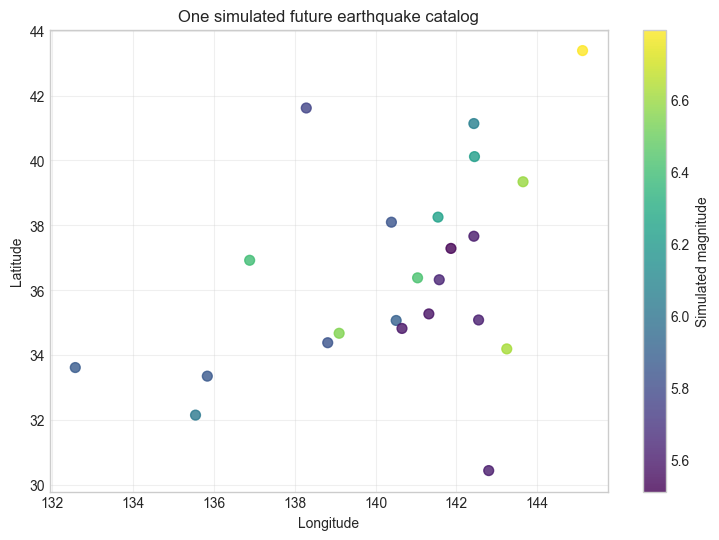

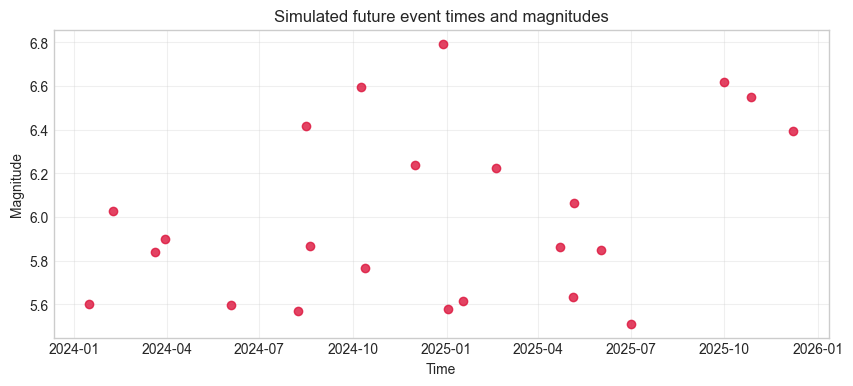

In [145]:
plt.figure(figsize=(9, 6))
plt.scatter(
    sim_one["longitude"],
    sim_one["latitude"],
    c=sim_one["mag"],
    cmap="viridis",
    s=50,
    alpha=0.8
)
plt.colorbar(label="Simulated magnitude")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("One simulated future earthquake catalog")
plt.grid(alpha=0.3)
plt.show()

if len(sim_one) > 0:
    plt.figure(figsize=(10, 4))
    plt.scatter(sim_one["time"], sim_one["mag"], c="crimson", alpha=0.8)
    plt.xlabel("Time")
    plt.ylabel("Magnitude")
    plt.title("Simulated future event times and magnitudes")
    plt.grid(alpha=0.3)
    plt.show()

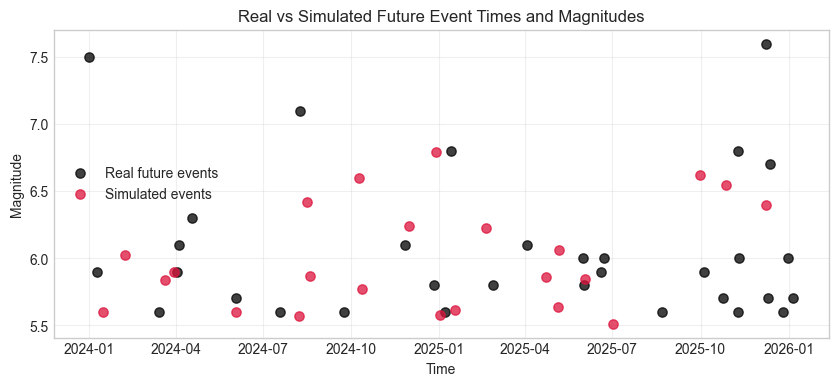

In [146]:
# compare simulated vs real future time series (same chart)

plt.figure(figsize=(10, 4))

# real test events
plt.scatter(
    raw_test["time"],
    raw_test["mag"],
    c="black",
    alpha=0.75,
    s=45,
    label="Real future events"
)

# simulated events
plt.scatter(
    sim_one["time"],
    sim_one["mag"],
    c="crimson",
    alpha=0.75,
    s=45,
    label="Simulated events"
)

plt.xlabel("Time")
plt.ylabel("Magnitude")
plt.title("Real vs Simulated Future Event Times and Magnitudes")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [147]:
# comparison of real test events and simulated events
print("real test summary")
print(f"number of real events: {len(raw_test)}")
print(f"max real magnitude: {raw_test['mag'].max():.3f}")
print(f"mean real magnitude: {raw_test['mag'].mean():.3f}")

print("\nsimulated test summary")
if len(sim_one) > 0:
    print(f"number of simulated events: {len(sim_one)}")
    print(f"max simulated magnitude: {sim_one['mag'].max():.3f}")
    print(f"mean simulated magnitude: {sim_one['mag'].mean():.3f}")
else:
    print("no simulated events")

real test summary
number of real events: 32
max real magnitude: 7.600
mean real magnitude: 6.066

simulated test summary
number of simulated events: 23
max simulated magnitude: 6.795
mean simulated magnitude: 6.005


In [138]:
# Monte Carlo simulation to get distribution of outcomes
n_sim = 300

sim_catalogs = []
sim_counts = []
sim_max_mag = []
sim_mean_mag = []
sim_ge7 = []

lon_edges = np.linspace(lon_min, lon_max, 30)
lat_edges = np.linspace(lat_min, lat_max, 30)
heat_sum = np.zeros((len(lat_edges) - 1, len(lon_edges) - 1))

for s in range(n_sim):
    sim_cat = simulate_future_catalog(
        history_times=history_times,
        start_t=start_t,
        end_t=end_t,
        mu=mu_hat,
        alpha=alpha_hat,
        beta=beta_hat,
        spatial_kde=spatial_kde,
        lon_min=lon_min,
        lon_max=lon_max,
        lat_min=lat_min,
        lat_max=lat_max,
        b0=b0,
        bt=bt,
        blon=blon,
        blat=blat,
        xi=xi_hat,
        u=u,
        t0=t0
    )

    sim_catalogs.append(sim_cat)

    sim_counts.append(len(sim_cat))

    if len(sim_cat) > 0:
        sim_max_mag.append(sim_cat["mag"].max())
        sim_mean_mag.append(sim_cat["mag"].mean())
        sim_ge7.append((sim_cat["mag"] >= 7.0).any())

        H, _, _ = np.histogram2d(
            sim_cat["latitude"],
            sim_cat["longitude"],
            bins=[lat_edges, lon_edges]
        )
        heat_sum += H
    else:
        sim_max_mag.append(np.nan)
        sim_mean_mag.append(np.nan)
        sim_ge7.append(False)

sim_counts_arr = np.array(sim_counts)
sim_max_mag_arr = np.array(sim_max_mag, dtype=float)
sim_mean_mag_arr = np.array(sim_mean_mag, dtype=float)
sim_ge7_arr = np.array(sim_ge7)
heat_mean = heat_sum / n_sim

print("Monte Carlo forecast summary")
print(f"number of simulations（how many different trajectories): {n_sim}")
print()
print(f"event count mean   = {sim_counts_arr.mean():.2f}")
print(f"event count median = {np.median(sim_counts_arr):.2f}")
print(f"event count 5%     = {np.quantile(sim_counts_arr, 0.05):.2f}")
print(f"event count 95%    = {np.quantile(sim_counts_arr, 0.95):.2f}")
print()
print(f"max magnitude mean = {np.nanmean(sim_max_mag_arr):.3f}")
print(f"max magnitude 95%  = {np.nanquantile(sim_max_mag_arr, 0.95):.3f}")
print(f"mean magnitude mean = {np.nanmean(sim_mean_mag_arr):.3f}")
print(f"P(at least one M>=7) = {sim_ge7_arr.mean():.3f}")#

Monte Carlo forecast summary
number of simulations（how many different trajectories): 300

event count mean   = 26.47
event count median = 25.00
event count 5%     = 14.00
event count 95%    = 44.00

max magnitude mean = 7.067
max magnitude 95%  = 7.864
mean magnitude mean = 5.960
P(at least one M>=7) = 0.523


In [155]:
mc_compare = pd.DataFrame({
    "Metric": [
        "Event count",
        "Maximum magnitude",
        "Mean magnitude",
        "P(at least one M>=7)"
    ],
    "Real test": [
        len(raw_test),
        round(raw_test["mag"].max(), 3),
        round(raw_test["mag"].mean(), 3),
        bool((raw_test["mag"] >= 7.0).any())
    ],
    "MC mean": [
        round(sim_counts_arr.mean(), 3),
        round(np.nanmean(sim_max_mag_arr), 3),
        round(np.nanmean(sim_mean_mag_arr), 3),
        round(sim_ge7_arr.mean(), 3)
    ],
    "MC median": [
        round(np.median(sim_counts_arr), 3),
        round(np.nanmedian(sim_max_mag_arr), 3),
        round(np.nanmedian(sim_mean_mag_arr), 3),
        np.nan
    ],
    "MC 5%": [
        round(np.quantile(sim_counts_arr, 0.05), 3),
        round(np.nanquantile(sim_max_mag_arr, 0.05), 3),
        round(np.nanquantile(sim_mean_mag_arr, 0.05), 3),
        np.nan
    ],
    "MC 95%": [
        round(np.quantile(sim_counts_arr, 0.95), 3),
        round(np.nanquantile(sim_max_mag_arr, 0.95), 3),
        round(np.nanquantile(sim_mean_mag_arr, 0.95), 3),
        np.nan
    ]
})

print("Comparison between real test data and Monte Carlo forecast")
print(mc_compare.to_string(index=False))

Comparison between real test data and Monte Carlo forecast
              Metric Real test  MC mean  MC median  MC 5%  MC 95%
         Event count        32   26.470     25.000 14.000  44.000
   Maximum magnitude       7.6    7.067      7.024  6.483   7.864
      Mean magnitude     6.066    5.960      5.958  5.808   6.120
P(at least one M>=7)      True    0.523        NaN    NaN     NaN


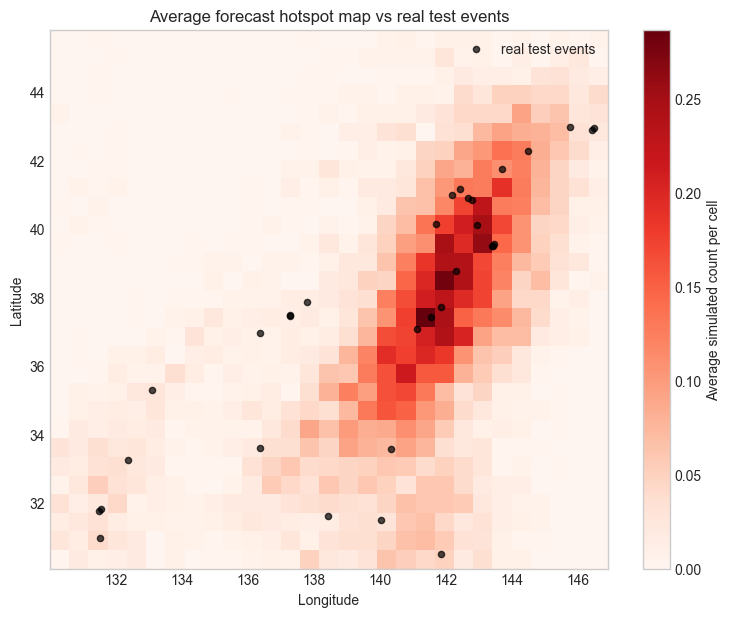

In [151]:
plt.figure(figsize=(9, 7))
plt.pcolormesh(lon_edges, lat_edges, heat_mean, shading="auto", cmap="Reds")
plt.colorbar(label="Average simulated count per cell")
plt.scatter(raw_test["longitude"], raw_test["latitude"], s=20, c="black", alpha=0.7, label="real test events")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Average forecast hotspot map vs real test events")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

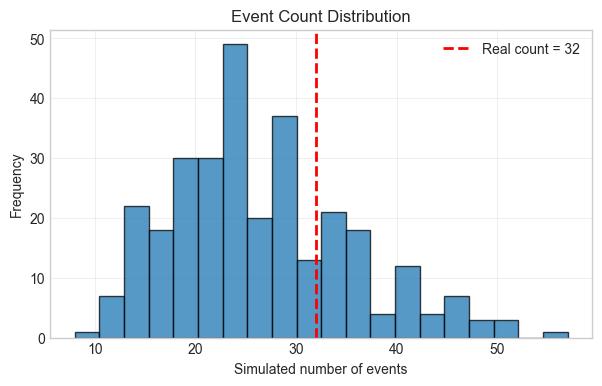

In [ ]:
# event count distribution
fig, ax = plt.subplots(figsize=(7,4))

ax.hist(sim_counts_arr, bins=20, alpha=0.75, edgecolor="black")
ax.axvline(len(raw_test), color="red", linestyle="--", linewidth=2, label=f"Real count = {len(raw_test)}")

ax.set_title("Event Count Distribution")
ax.set_xlabel("Simulated number of events")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

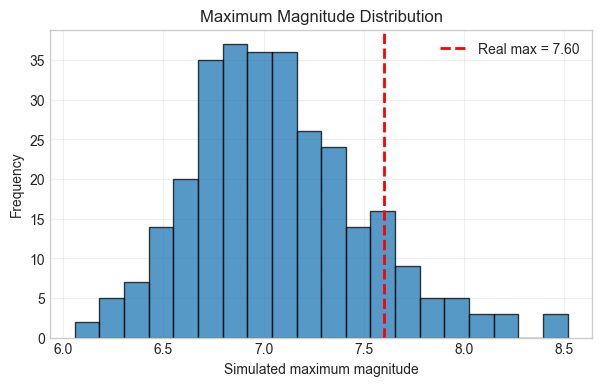

In [150]:
# Maximum Magnitude Distribution
fig, ax = plt.subplots(figsize=(7, 4))

valid_max = sim_max_mag_arr[~np.isnan(sim_max_mag_arr)]

ax.hist(valid_max, bins=20, alpha=0.75, edgecolor="black")
ax.axvline(raw_test["mag"].max(), color="red", linestyle="--", linewidth=2, label=f"Real max = {raw_test['mag'].max():.2f}")

ax.set_title("Maximum Magnitude Distribution")
ax.set_xlabel("Simulated maximum magnitude")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

The event count and maximum magnitude histograms show that the real test values lie within the simulated ranges, indicating reasonable predictive accuracy. The spatial heatmap also aligns well with the main locations of observed events. Overall, the model captures frequency, size, and location patterns satisfactorily.
